In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df=pd.read_csv(r"D:\BDA_0024\AML_LAB\project_lab_5\data\income_data.csv")

In [3]:
df

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
...,...,...,...
493,494,5.249209,4.568705
494,495,3.471799,2.535002
495,496,6.087610,4.397451
496,497,3.440847,2.070664


In [4]:
df.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
X=df[["income"]]
y=df["happiness"]

In [7]:
X

,income
0,3.862647
1,4.979381
2,4.923957
3,3.214372
4,7.196409
...,...
493,5.249209
494,3.471799
495,6.087610
496,3.440847


In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.72]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1417
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [10]:
y_pred=model.predict(X_test)

In [11]:
print("Actual values: ",y_test.values)
print("predicted values: ",y_pred)

Actual values:  [4.75416839 4.1596093  2.29570014 2.31155424 2.86127444 1.96563593
 4.57080113 4.00453774 1.46061633 3.73794161 4.83350643 3.05738784
 3.06760945 2.78424454 2.15584332 2.96216821 2.23344058 6.29910126
 1.83980201 2.96195666 2.33627603 4.2452156  2.11513648 1.30848726
 4.71966533 0.77128657 2.67988732 4.98525493 3.80429886 4.8266027
 0.69845996 3.04079729 2.39167752 4.5993734  3.73056996 3.70343793
 0.96852733 3.45310274 1.41666106 1.41022957 5.83619666 4.3284171
 5.9142477  5.3139569  2.31448898 2.00904646 2.57505486 3.02072445
 2.20098217 0.26604366 3.98112774 3.22747217 5.26547896 4.93304409
 2.66611603 4.30728842 3.99041589 4.56870456 5.68375056 3.94101932
 4.32466038 1.92757883 5.15933124 4.08382116 2.45320906 4.68281699
 4.28430556 4.0564931  2.41338175 4.72098734 4.63344105 2.94753147
 1.77593255 2.20824052 0.54836519 4.21269734 4.25831153 5.03400379
 3.58387516 4.3213643  3.87278885 2.96732327 2.57693996 3.3427494
 2.77968263 2.39322812 4.51696059 4.55321655 2.25

In [12]:
print("Intercept : ",model.intercept_)


Intercept :  0.14170387227353531


In [13]:
print("Slope : ",model.coef_[0])

Slope :  0.7247687016076183


In [14]:
new_year_experience=pd.DataFrame({
    "income":[5.2000]
})

In [15]:
prediction=model.predict(new_year_experience)
print("Predicted Final Mark: ",prediction[0])

Predicted Final Mark:  3.9105011206331506


In [16]:
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R-Squared : ",r2_score(y_test,y_pred))

MAE :  0.6269683431894553
MSE :  0.590146394343082
RMSE :  0.768209863476825
R-Squared :  0.6662585264303965


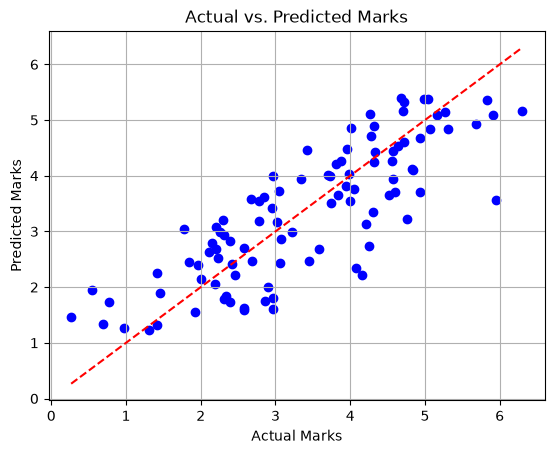

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color="blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
[minimum, maximum],
[minimum, maximum],
color="red",
linestyle="--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs. Predicted Marks")
plt.grid(True)
plt.show()

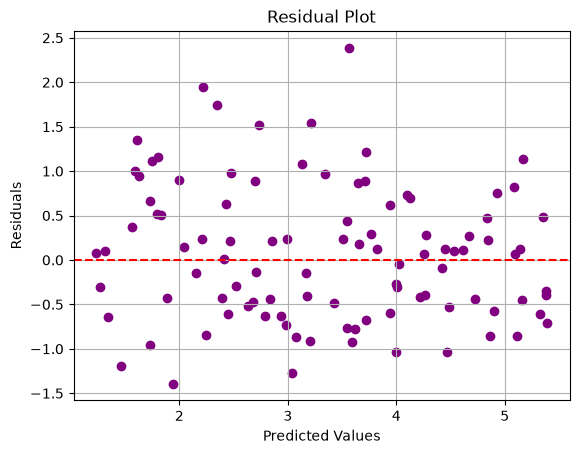

In [18]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [22]:
model=make_pipeline(StandardScaler(),Ridge(alpha=1.0))

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [23]:
for alpha in [0.01,0.1,1,10,100]:
    model=Ridge(alpha=alpha)
    model.fit(X_train,y_train)

In [27]:
from sklearn.linear_model import RidgeCV

model=RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)
model.fit(X_train,y_train)

print("Best alpha: ",model.alpha_)

Best alpha:  10.0


In [28]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
)

model.fit(X_train, y_train)

ridge_model = model.named_steps["ridgecv"]

print("Best alpha:", ridge_model.alpha_)

Best alpha: 0.1
